In [1]:
# NUMERICAL & DATA MANIPULATION

import pandas as pd
import numpy as np

# DATA VISUALIZATION

import matplotlib.pyplot as plt
import seaborn as sns

### **Data import**

In [2]:
# CREATE A DATA FRAME FROM EACH CSV FILE IN THE DATA FOLDER

customers = pd.read_csv('data/olist_customers_dataset.csv')
order_items = pd.read_csv('data/olist_order_items_dataset.csv')
orders = pd.read_csv('data/olist_orders_dataset.csv')
products = pd.read_csv('data/olist_products_dataset.csv')


### **EDA**

The content of each single dataset is explored to ensure consistency and spot possible issues.

##### **Customers dataset**

All data formats are appropriate and no null values are present in the data frame

In [3]:
# DISPLAY TOP TWO ROWS IN THE DATAFRAME

customers.head(2)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP


In [4]:
# INSPECT DATAFRAME MEDTADATA INCLUDING ENTRIES, COLUMNS, NON-NULL COUNTS, AND DATA TYPES.

customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [5]:
# CHECK NUMBER OF NULL VALUES PER COLUMN

customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

The data frame currently contains no duplicate records. However, as a best practice and to ensure robustness, an additional line of code will be included to prevent potential duplication if new data entries are introduced in the future.

In [6]:
# CHECK IF THE DATAFRAME CONTAINS DUPLICATED DATA.

print(f'The customer dataframe has {customers.duplicated().sum()} duplicated entries.')

The customer dataframe has 0 duplicated entries.


In [7]:
# MAKE SURE CUSTOMER_ID CONTAINS ONLY UNIQUE VALUES, OTHERWISE THE CODE WILL BREAK AND STOP HERE IF FUTURES ENTRIES INTRODUCE DUPLICATES 

assert customers['customer_id'].is_unique

The number of unique values in the customer_id and customer_unique_id do not match.
This discrepancy is expected, as a new customer_id is assigned to each individual purchase made by the same unique customer (customer_unique_id), resulting in duplicated values in the customer_unique_id column.
That means customer_id is the primary key of the data frame, which also appears as a foreign key in other frames. Using customer_id ensures that all orders can be merged correctly and consistently mapped across datasets.

In [8]:
# DISPLAY THE NUMBER OF UNIQUE VALUES PER COLUMN

customers.nunique(dropna=False)

customer_id                 99441
customer_unique_id          96096
customer_zip_code_prefix    14994
customer_city                4119
customer_state                 27
dtype: int64

In [9]:
# DISPLAY THE NUMBER OF UNIQUE VALUES (FALSE) AND DUPLICATED VALUES (TRUE) IN THE CUSTOMER_UNIQUE_ID

customers['customer_unique_id'].duplicated().value_counts()

customer_unique_id
False    96096
True      3345
Name: count, dtype: int64

**Adjustments**

To improve geographic clarity, the customer_state feature will be updated to use full state names instead of abbreviations.

States

In [10]:
# CHECK ACTUAL VALUES WITHIN THE CUSTOMER STATE FEATURE

customers['customer_state'].unique()

array(['SP', 'SC', 'MG', 'PR', 'RJ', 'RS', 'PA', 'GO', 'ES', 'BA', 'MA',
       'MS', 'CE', 'DF', 'RN', 'PE', 'MT', 'AM', 'AP', 'AL', 'RO', 'PB',
       'TO', 'PI', 'AC', 'SE', 'RR'], dtype=object)

In [11]:
# DEFINE A DICTIONARY WITH THE STATE ABBREVIATION AND ACTUAL NAME

brasil_states = {
    'AC': 'Acre', 'AL': 'Alagoas', 'AP': 'Amapá', 'AM': 'Amazonas',
    'BA': 'Bahia', 'CE': 'Ceará', 'DF': 'Distrito Federal', 'ES': 'Espírito Santo',
    'GO': 'Goiás', 'MA': 'Maranhão', 'MT': 'Mato Grosso', 'MS': 'Mato Grosso do Sul',
    'MG': 'Minas Gerais', 'PA': 'Pará', 'PB': 'Paraíba', 'PR': 'Paraná',
    'PE': 'Pernambuco', 'PI': 'Piauí', 'RJ': 'Rio de Janeiro', 'RN': 'Rio Grande do Norte',
    'RS': 'Rio Grande do Sul', 'RO': 'Rondônia', 'RR': 'Roraima', 'SC': 'Santa Catarina',
    'SP': 'São Paulo', 'SE': 'Sergipe', 'TO': 'Tocantins'
}

# REPLACE ABBREVIATION BY ACTUAL STATE NAMES

customers['customer_state'] = customers['customer_state'].map(brasil_states)

# CHECK ADJUSTMENT

print(customers['customer_state'].head(3))


0    São Paulo
1    São Paulo
2    São Paulo
Name: customer_state, dtype: object


##### **Order items dataset**

There are no null values present, and most data types are correctly assigned. However, the shipping_limit_date column needs to be converted to a datetime format, as it is currently stored as an object.

In [12]:
# DISPLAY TOP TWO ROWS IN THE DATAFRAME

order_items.head(2)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93


In [13]:
# INSPECT DATAFRAME MEDTADATA INCLUDING ENTRIES, COLUMNS, NON-NULL COUNTS, AND DATA TYPES.

order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [14]:
# CHECK NUMBER OF NULL VALUES PER COLUMN

order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

**Adjusting wrond data types**

In [15]:
# TRANSFORM THE SHIPPING_LIMIT_DATE DATA TYPE FROM OBJECT TO DATE

order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'], errors= 'coerce')

In [16]:
# DISPLAY THE NEW DATA TYPE FOR SHIPPING_LIMIT_DATE

order_items['shipping_limit_date'].dtype

dtype('<M8[ns]')

The data frame currently contains no duplicate records. However, as a best practice and to ensure robustness, an additional line of code will be included to prevent potential duplication if new data entries are introduced in the future.

In [17]:
# CHECK IF THE DATAFRAME CONTAINS DUPLICATED DATA.

print(f'The order items dataframe has {order_items.duplicated().sum()} duplicated entries.')

The order items dataframe has 0 duplicated entries.


In [18]:
# MAKE SURE ORDER_ID AND ORDER_ITEMS ARE UNIQUE, OTHERWISE THE CODE WILL BREAK AND STOP HERE IF FUTURES ENTRIES INTRODUCE DUPLICATES 

assert not order_items.duplicated(['order_id','order_item_id']).any()

The number of unique values in the order_id column (98,666) is lower than the total number of records in the orders DataFrame (99,491). This discrepancy is likely due to orders that were canceled, recently placed, or are still in an initial status but went lost

This issue will be addressed once the Data frames are merged and the order lifecycle is analyzed more comprehensively.

In [19]:
# DISPLAY THE NUMBER OF UNIQUE VALUES PER COLUMN

order_items.nunique(dropna= False)

order_id               98666
order_item_id             21
product_id             32951
seller_id               3095
shipping_limit_date    93318
price                   5968
freight_value           6999
dtype: int64

##### **Orders dataset**

The orders dataset requires special attention in the following areas:

* **Date and time fields** are incorrectly formatted as objects and need to be converted to proper date or datetime formats.
* **Check the order status** to be sure all orders have been delivered as the data is not recent
* **Check the data distribution** based on the year and month
* **Missing (null) values** are present; a more in-depth exploratory analysis will be conducted to determine the appropriate handling strategy for these records.

In [20]:
# DISPLAY TOP TWO ROWS IN THE DATAFRAME

orders.head(2)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00


In [21]:
# INSPECT DATAFRAME MEDTADATA INCLUDING ENTRIES, COLUMNS, NON-NULL COUNTS, AND DATA TYPES.

orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


The data frame currently contains no duplicate records. However, as a best practice and to ensure robustness, an additional line of code will be included to prevent potential duplication if new data entries are introduced in the future.

In [22]:
# CHECK IF THE DATAFRAME CONTAINS DUPLICATED DATA.

print(f'The orders dataframe has {orders.duplicated().sum()} duplicated entries.')

The orders dataframe has 0 duplicated entries.


In [23]:
# MAKE SURE ORDER_ID CONTAINS ONLY UNIQUE VALUES, OTHERWISE THE CODE WILL BREAK AND STOP HERE IF FUTURES ENTRIES INTRODUCE DUPLICATES 

assert orders['order_id'].is_unique

**Handling wrong data types**

In [24]:
# LIST OF COLUMNS THAT SHOULD BE DATETIME BUT CURRENTLY HAVE THE WRONG DATA TYPE.

dates = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


# APPLY CORRECT DATA TYPE TO THE LISTED COLUMNS

orders[dates] = orders[dates].apply(pd.to_datetime, errors= 'coerce')


In [25]:
# CHECK THE NEW DATA TYPES HAVE BEEN CONVERTED PROPERLY

orders.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

**Is the data consistent throughout the time?**

Data collection issues were identified in 2017, along with, what seems to be, a reporting lag starting in September 2018. To maintain the integrity of the study and prevent these inconsistencies from distorting the results, these periods have been excluded from the analysis.

In [26]:
# ADD A YEAR, MONTH, AND ISOWEEK COLUMN FOR EACH ORDER

orders['year'] = orders['order_purchase_timestamp'].dt.year
orders['month'] = orders['order_purchase_timestamp'].dt.month_name()
orders['iso_week'] = orders['order_purchase_timestamp'].dt.isocalendar()['week']

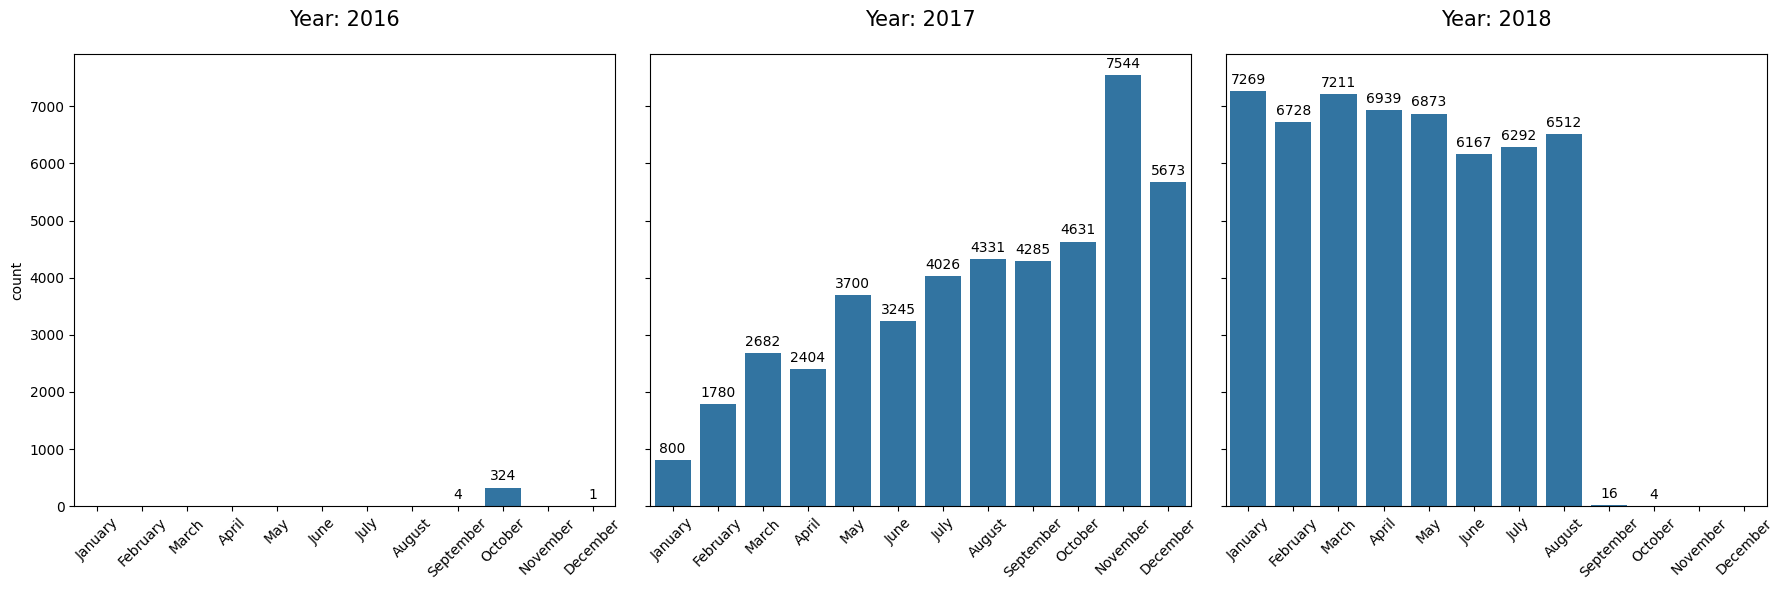

In [27]:
# GENERATE A BAR CHART WITH ALL ORDERS PER YEAR AND MONTH

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

years = sorted(orders['year'].unique())
rows_chart_1 = int(np.ceil(len(years) / 3))


fig, axes = plt.subplots(rows_chart_1, 3, figsize=(18, 6), sharey=True)
axes = axes.flatten()

for i, time in enumerate(years):
    data_year = orders[orders['year'] == time]
    
    
    plot = sns.countplot(data=data_year, x='month', ax=axes[i], order=month_order)
    

    axes[i].bar_label(axes[i].containers[0], padding=3, fontsize=10)

    
    axes[i].set_title(f'Year: {time}', fontsize=15, pad=20)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [28]:
# FILTER OUT ORDERS IN PLACED IN 2016 AND FROM AUGUST 2018 ONWARDS

orders = orders[(orders['order_purchase_timestamp'] >= '2017-01-01') & (orders['order_purchase_timestamp'] < '2018-09-01')]


In [29]:
orders.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,year,month,iso_week
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,October,40
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,July,30
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,August,32


In [30]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99092 entries, 0 to 99440
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99092 non-null  object        
 1   customer_id                    99092 non-null  object        
 2   order_status                   99092 non-null  object        
 3   order_purchase_timestamp       99092 non-null  datetime64[ns]
 4   order_approved_at              98957 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97376 non-null  datetime64[ns]
 6   order_delivered_customer_date  96204 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99092 non-null  datetime64[ns]
 8   year                           99092 non-null  int32         
 9   month                          99092 non-null  object        
 10  iso_week                       99092 non-null  UInt32        
dtypes: UInt32(1), dateti

**Have all orders been delivered?**

The orders were dispatched between 2016 and 2018. However, a significant number of them were not delivered and still appeared under statuses such as shipped, unavailable, invoiced, processing, created, or approved status.

Since it is not possible to determine what ultimately happened to these orders, any order that was neither delivered nor canceled is considered lost.

In [31]:
# SHOW THE NUMBER OF ORDERS BY THE ORDER STATUS

orders['order_status'].value_counts(dropna= False)

order_status
delivered      96211
shipped         1097
unavailable      602
canceled         580
processing       299
invoiced         296
created            5
approved           2
Name: count, dtype: int64

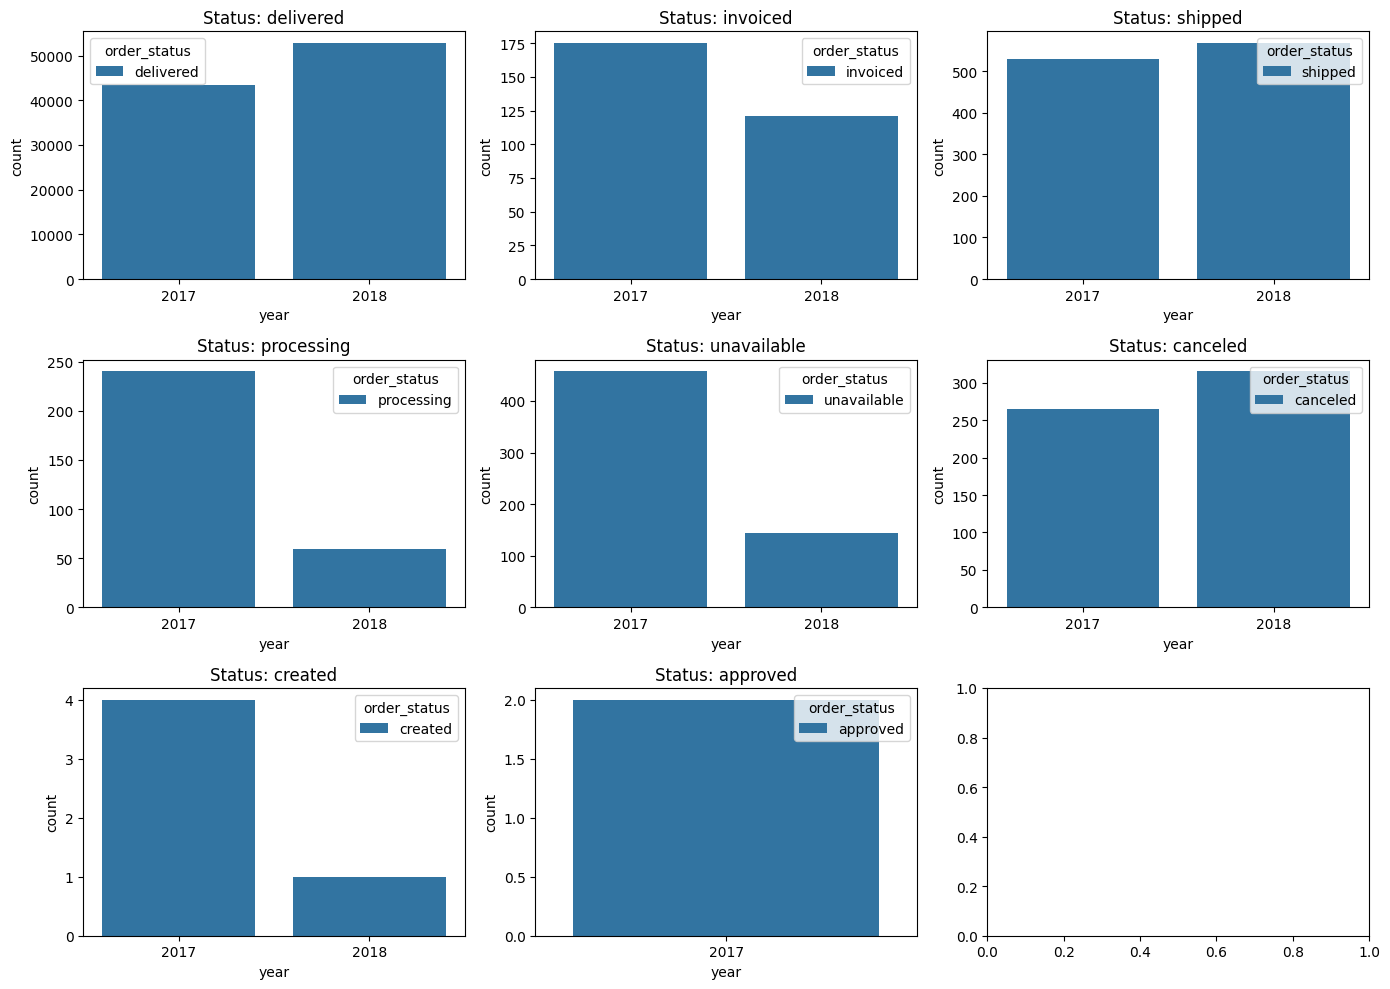

In [32]:
# EXTRACT UNIQUE VALUES CONTAINED IN THE ORDER_STATUS COLUMN
unique_statuses = orders['order_status'].unique()

# DEFINE THE GRID FOR THE CHARTS
rows_chart_2 = int(np.ceil( len(unique_statuses) / 3))
fig, axes = plt.subplots(rows_chart_2, 3, figsize=(14, 10))

# CONVERT A 3x3 MATRIX INTO A FLAT LIST OF 9 ELEMENTS
axes = axes.flatten()

# RUN A LOOP TO GENERATE ALL CHARTS
for ii, status in enumerate(unique_statuses):

    filter_data = orders[orders['order_status'] == status]
    sns.countplot(data=filter_data, x='year', hue='order_status', ax=axes[ii])
    axes[ii].set_title(f"Status: {status}")
    
plt.tight_layout()

    

In [33]:
# CATEGORIZE THE ORDER_STATUS BETWEEN DELIVERED, CANCELED, OR LOST

orders['order_status_real'] = orders['order_status'].apply(lambda x: 'delivered' if x == 'delivered'
                                                        else 'canceled' if x == 'canceled'
                                                        else 'lost' )

In [34]:
# SHOW THE NUMBER OF ORDERS BY THE ORDER STATUS

orders['order_status_real'].value_counts()

order_status_real
delivered    96211
lost          2301
canceled       580
Name: count, dtype: int64

**Handling null values**

Null values affect three features: order_approved_at, order_delivered_carrier_date, and order_delivered_customer_date.
The absence of values in these fields is expected in many cases, as they are mostly associated with orders that were canceled or lost at some point during process. However, a small number of orders marked as delivered (23 cases) also contain missing values, which may indicate issues in the data collection or recording process.
Based on this analysis, the null values will be retained, since in most cases they correctly reflect orders that were canceled or parcels that were lost.

In [35]:
# DISPLAY NUMBER OF NULL VALUES PER COLUMN

orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 135
order_delivered_carrier_date     1716
order_delivered_customer_date    2888
order_estimated_delivery_date       0
year                                0
month                               0
iso_week                            0
order_status_real                   0
dtype: int64

In [36]:
# GENERATE A DATA FRAME WITH ALL ENTRIES CONTAINING AT LEAST A NULL VALUE

orders_nulls = orders.loc[orders.isnull().any(axis=1)].copy()


# DISPLAY TOP 3 ROWS OF THE NEWLY CREATED MISSING_DATA FRAME

orders_nulls.head(3)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,year,month,iso_week,order_status_real
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09,2017,April,15,lost
44,ee64d42b8cf066f35eac1cf57de1aa85,caded193e8e47b8362864762a83db3c5,shipped,2018-06-04 16:44:48,2018-06-05 04:31:18,2018-06-05 14:32:00,NaT,2018-06-28,2018,June,23,lost
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaT,NaT,2018-08-21,2018,August,31,lost


In [37]:
# DISTRIBUTION OF NULLS BY ORDER STATUS

orders_nulls['order_status_real'].value_counts()

order_status_real
lost         2301
canceled      579
delivered      23
Name: count, dtype: int64

##### **Products dataset**

All formats make sense. However, there is an important number of null values that need further review and handling.

In [38]:
# DISPLAY TOP TWO ROWS IN THE DATAFRAME

products.head(2)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0


In [39]:
# INSPECT DATAFRAME MEDTADATA INCLUDING ENTRIES, COLUMNS, NON-NULL COUNTS, AND DATA TYPES.

products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


**Handling nulls values**

Most of the missing values affect production related KPIs such as category name, name length, product description length, and number of pictures. This may indicate that these products are new additions to the catalog and had not yet been processed at the time of data extraction.

In [40]:
# CHECK NUMBER OF NULL VALUES PER COLUMN

products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

The products affected by nulls have all driven sales and therefore, due to their relevance they will be kept as they are to avoid distortions, except for the category_column_name, which is going to be treated as 'unkown'.

In [41]:
# CREATE A DATA FRAME WITH ALL NULLS

products_nulls = products.loc[products.isnull().any(axis=1)]

# CREATE A DATA FRAME WITH REVENUEW GENERATED BY EACH PRODUCT

products_revenue = order_items[['product_id', 'price']].groupby(by= 'product_id', as_index= False).sum()

In [42]:
# JOIN THE PRODUCTS WITH NULLS AND THEIR REVENUE

products_null_revenue = pd.merge(left= products_nulls['product_id'] ,right= products_revenue, how= 'inner', on= 'product_id')

In [43]:
# CHECK THE TOTAL REVENUE GENERATED BY THE PRODUCTS AFFECTED BY NULLS

print(f'All products have generated sales for {products_null_revenue.price.sum()}')

# CHECK IF THERE ARE NULLS IN THE PRICE COLUMN

print(f'There are no missing values ({products_null_revenue.price.isnull().sum()} duplicates) indicating that every product has been sold at least once')

# DISPLAY THE TOP THREE ENTRIES STARTING BY THE LOWEST REVENUE

products_null_revenue.sort_values(by= 'price').head(3)


All products have generated sales for 181469.28
There are no missing values (0 duplicates) indicating that every product has been sold at least once


,product_id,price
103,dc9f66a56b89e4278d921898a861a29a,3.90
581,2cd7d0ade9eb52c856a16dce303397ad,4.85
324,28fff36d13d492328583ee2b1d72f78f,5.20


Filling the null values from the product_category_name with 'unknown'

In [44]:
# FILL NULLS VALUES FROM THE PRODUCT_CATEGORY_NAME WITH 'UNKNOWN'

products['product_category_name'] = products['product_category_name'].fillna('unknown')


In [45]:
# CHECK NUMBER OF NULLS PER COLUM

products.isnull().sum()

product_id                      0
product_category_name           0
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

The data frame currently contains no duplicate records. However, as a best practice and to ensure robustness, an additional line of code will be included to prevent potential duplication if new data entries are introduced in the future.

In [46]:
# CHECK IF THE DATAFRAME CONTAINS DUPLICATED DATA.

print(f'The product dataframe has {products.duplicated().sum()} duplicated entries.')

The product dataframe has 0 duplicated entries.


In [47]:
# MAKE SURE PRODUCT_ID CONTAINS ONLY UNIQUE VALUES, OTHERWISE THE CODE WILL BREAK AND STOP HERE IF FUTURES ENTRIES INTRODUCE DUPLICATES 

assert products['product_id'].is_unique

In [48]:
# DISPLAY THE NUMBER OF UNIQUE VALUES PER COLUMN

products.nunique(dropna= False)

product_id                    32951
product_category_name            74
product_name_lenght              67
product_description_lenght     2961
product_photos_qty               20
product_weight_g               2205
product_length_cm               100
product_height_cm               103
product_width_cm                 96
dtype: int64

### **Defining final data frames for analysis**

First, the most relevant KPIs will be defined to allow them to be merged and to ensure the most meaningful data is obtained.

In [49]:
# GENERATE THE FINAL FRAMES THAT WILL BE MERGED

customers_final = customers.copy()

orders_final = orders[['order_id', 'customer_id', 'order_status_real', 'order_purchase_timestamp', 'year', 'month', 'iso_week', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']].copy()

order_items_final = order_items[['order_id', 'product_id', 'seller_id', 'order_item_id', 'price', 'freight_value']].copy()

products_final = products[['product_id', 'product_category_name', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']].copy()

### **1. Orders**

**a. Data frames adjustments**

**Defining Data frames**

In [50]:
# DEFINE AN AGGREGATED FRAME WITH THE RELEVENAT COLUMNS FROM THE ORDER_ITEMS DATA FRAME

agg_items = order_items_final.groupby(by= 'order_id', as_index= False).agg(
                                                                        number_items = ('product_id', 'count'),
                                                                        gmv_order = ('price', 'sum'),
                                                                        order_freight = ('freight_value', 'sum'))

# CREATE A COPY OF THE ORDERS_FINAL DATA FRAME TO AVOID CONTAMINATION WHEN RUNNING THE MERGING LOOP

orders_final_copy = orders_final.copy()

**Is the number of orders consistent in both data frames?**

Approximately 0.7% of the order_ids present in the orders_final_copy data frame are not found in the agg_items data frame, affecting 739 records distributed between canceled and lost orders.

The agg_items data frame will be merged into orders_final_copy using a left join, with orders_final_copy serving as the base (left) table. This approach ensures that all records from orders_final_copy are preserved.

Any null values generated during the merge process will be evaluated and handled in a subsequent data handling step.

In [51]:
# FILTER OUT ORDERS THAT ARE NOT CONATINED IN ORDER_ITEMS_FINAL

missing_records = orders_final_copy[~orders_final_copy['order_id'].isin(agg_items['order_id'])]

# COUNT THE NUMBER OF MISSING RECORDS

count_missing_records = missing_records['order_id'].count()

# CALCULATE THE % OF MISSING RECORDS

percent_missing_records = round((count_missing_records / orders_final_copy['order_id'].count()) * 100, 2)


In [52]:
# PRINT A MESSAGE IN CASE THE ORDER_ITEMS_FINAL DATASET CONTAINS OR NOT FEWER RECORDS THAN IN THE ORDERS_FINALS DATASET

if count_missing_records > 0:
    print(f'the order_items_final data frame does not contain {percent_missing_records}% ({count_missing_records}) of the total records in the orders_final dataset.')
    print('Those missing records are distributed as follows:\n')
    print(missing_records['order_status_real'].value_counts())

else: 
    print('The order_items_final dataset contains all entries included in the orders_final dataset.')

the order_items_final data frame does not contain 0.75% (739) of the total records in the orders_final dataset.
Those missing records are distributed as follows:

order_status_real
lost        607
canceled    132
Name: count, dtype: int64


**b. Mergin the frames**

In [53]:
# LIST THE DATA FRAMES AND JOIN KEYS USE TO MERGE

orders_mergin_parameters = [(customers_final, 'customer_id'), (agg_items, 'order_id')]

# RUN A LOOP TO MERGE ALL DATA FRAMES

for frame, order_join_key in orders_mergin_parameters:
    
    df_orders = pd.merge(left= orders_final_copy, right= frame, how= 'left', on= order_join_key)
    orders_final_copy = df_orders
    
# DISPLAY THE TOP 3 ROWS OF THE NEWLY MERGED DATA FRAME

df_orders.head(3)

,order_id,customer_id,order_status_real,order_purchase_timestamp,year,month,iso_week,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,number_items,gmv_order,order_freight
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017,October,40,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,São Paulo,1.0,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018,July,30,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,Bahia,1.0,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018,August,32,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,Goiás,1.0,159.90,19.22


In [54]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99092 entries, 0 to 99091
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99092 non-null  object        
 1   customer_id                    99092 non-null  object        
 2   order_status_real              99092 non-null  object        
 3   order_purchase_timestamp       99092 non-null  datetime64[ns]
 4   year                           99092 non-null  int32         
 5   month                          99092 non-null  object        
 6   iso_week                       99092 non-null  UInt32        
 7   order_delivered_carrier_date   97376 non-null  datetime64[ns]
 8   order_delivered_customer_date  96204 non-null  datetime64[ns]
 9   order_estimated_delivery_date  99092 non-null  datetime64[ns]
 10  customer_unique_id             99092 non-null  object        
 11  customer_zip_co

**Assigning correct data types**

In [55]:
# ASSIGN INTEGER AS DATA TYPE FOR THE COLUMN NUMBER_ITEMS

df_orders['number_items'] = df_orders['number_items'].convert_dtypes('int')

# DISPLAY NEW DATA TYPE FOR COLUMN NUMBER_ITEMS

df_orders['number_items'].dtype

Int64Dtype()

**Handling Null Values generated by the merging**

The proportion of null values in the frame generated by the merging is relatively small, representing approximately 0.7% of the total records. Given this low share, and considering the presence of a significant number of outliers in the features number_items, gmv_order, and freight, records containing null values in these features will be removed from the data frame.

Dropping these records helps preserve data integrity and avoids introducing potential bias or distortion that could result from imputing values that may not accurately reflect the underlying data distribution.

In [56]:
# CECHK NUMBER OF NULL VALUES PER FEATURE

df_orders.isnull().sum()

order_id                            0
customer_id                         0
order_status_real                   0
order_purchase_timestamp            0
year                                0
month                               0
iso_week                            0
order_delivered_carrier_date     1716
order_delivered_customer_date    2888
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
number_items                      739
gmv_order                         739
order_freight                     739
dtype: int64

In [57]:
# PROVE THAT THE NUMBER OF MISSING RECORDS IN THE AGG_ITEMS DATA FRAME IS NOT GREATER OR EQUAL TO 3% OF THE TOTAL RECORDS IN THE ORDERS_FINAL_COPY, OTHERWISE THE CODE WILL BREAK AND STOP HERE

# _NOTE_:
# IF THE CODE STOPS HERE, DECIDE WISELY HOW TO HANDLE NULL VALUES AS FILTERING THEM OUT MIGHT NOT LONGER BE THE BEST APPROACH


assert percent_missing_records < 3

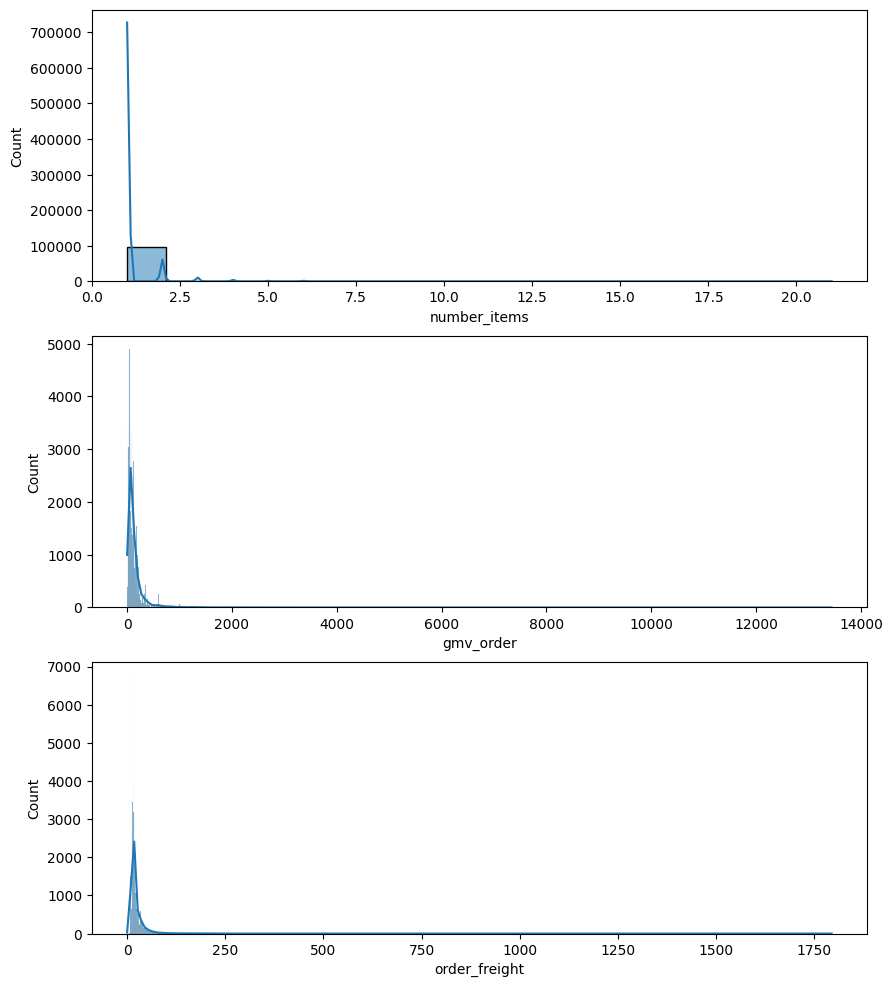

In [58]:
# DEFINE THE TARGET FEATURES

col_graph = ['number_items', 'gmv_order', 'order_freight']

# CRATE A CHART WITH THE DISTRIBUTION OF EACH FEATURE INCLUDED IN THE COL_GRAPH VARIABLE

fig, axes = plt.subplots(3,1, figsize = (10,12))
axes = axes.flatten()

for a, column in enumerate(col_graph):
    sns.histplot(data=df_orders, x= column, ax= axes[a],kde=True)



In [59]:
# FILTER OUT THE NULL VALUES GENERATED BY THE MERGING AND DEFINE THE DEFENETIVE DF_ORDERS DATA FRAME

df_orders = df_orders[df_orders['order_id'].isin(order_items_final['order_id'])].copy()

# CHECK IF THE NULL VALUES IN THE NUMBER_ITEMS; GMV_ORDER, AND ORDER_FREIGHT HAVE BEEN CORRECTLY FILTERED

df_orders.isnull().sum()



order_id                            0
customer_id                         0
order_status_real                   0
order_purchase_timestamp            0
year                                0
month                               0
iso_week                            0
order_delivered_carrier_date      977
order_delivered_customer_date    2149
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
number_items                        0
gmv_order                           0
order_freight                       0
dtype: int64

**Creating a file specifically for a Tableau side project**

In [60]:
# CREATE A CSV FILE FOR A SIDE TABLEAU PROJECT
# THE FILE HAS BEEN CREATED AT THIS POINT TO PERFORM FEATURE ENGINEERING IN TABLEAU AND DEMONSTRATE KNOWLEDGE OF THE TOOL
 
df_orders.to_csv('cleaned_data/orders.csv', index= False)

**c. Feature engeeniring**

Additional features have been engineered to capture order value and basket characteristics status information (delivered, canceled, or lost).

Furthermore, time-based features derived from the order and delivery timestamps allow us to evaluate logistics performance, such as shipping time, delivery delays, and carrier handling time.

In [61]:
# DISPLAY MAIN STATISTICS FOR ALL FEATURES

df_orders.describe().round(2)

,order_purchase_timestamp,year,iso_week,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix,number_items,gmv_order,order_freight
count,98353,98353.00,98353.0,97376,96204,98353,98353.00,98353.0,98353.00,98353.00
mean,2018-01-02 08:21:00.924578048,2017.55,24.28,2018-01-06 04:16:29.294775040,2018-01-15 18:18:53.662695936,2018-01-26 00:26:53.746403328,35146.34,1.14,137.68,22.82
min,2017-01-05 11:56:06,2017.00,1.0,2017-01-06 12:43:41,2017-01-11 13:14:05,2017-02-01 00:00:00,1003.00,1.0,0.85,0.00
25%,2017-09-14 09:35:42,2017.00,13.0,2017-09-18 21:42:32.500000,2017-09-26 21:48:51.249999872,2017-10-05 00:00:00,11350.00,1.0,45.90,13.85
50%,2018-01-20 17:06:24,2018.00,23.0,2018-01-24 20:24:30,2018-02-03 03:33:24.500000,2018-02-16 00:00:00,24422.00,1.0,86.90,17.17
75%,2018-05-05 10:18:35,2018.00,33.0,2018-05-08 14:14:00,2018-05-16 12:56:30.500000,2018-05-28 00:00:00,58900.00,1.0,149.90,24.03
max,2018-08-29 15:00:37,2018.00,52.0,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,99990.00,21.0,13440.00,1794.96
std,NaN,0.50,14.04,NaN,NaN,NaN,29795.86,0.54,210.68,21.66


Order Features

In [62]:
# ADD FLAGS INDICATING WEATHER AN ORDER WAS CANCELED, FAILED, OR SUCCESFULLLY DELIVERED

df_orders['is_canceled'] = df_orders['order_status_real'] == 'canceled'
df_orders['is_lost'] = df_orders['order_status_real'] == 'lost'
df_orders['is_delivered'] = df_orders['order_status_real'] == 'delivered'

Logistic Features

In [63]:
# ADD COLUMNS WITH THE ESTIMATED AND ACTUAL NUMBER OF DAYS FROM ORDER PURCHASE TO DELIVERY

df_orders['estimated_days_for_delivery'] = (df_orders['order_estimated_delivery_date'] - df_orders['order_purchase_timestamp']).dt.days
df_orders['actual_days_for_delivery'] = (df_orders['order_delivered_customer_date'] - df_orders['order_purchase_timestamp']).dt.days

# ADD A COLUMN WITH THE NUMBER OF DAYS NEEDED FOR DELIVERY VS. ESTIMATED DELIVERY

df_orders['delivery_delay_days'] = (df_orders['order_delivered_customer_date'].dt.floor('D') - df_orders['order_estimated_delivery_date']).dt.days

# FLAG IF ORDERS WERE DELIVERED ON TIME OR NOT

df_orders['delivered_on_time'] = df_orders['delivery_delay_days'] <= 0

# ADD COLUMNS WITH THE ACTUAL NUMBER OF DAYS FROM THE ORDER PURCHASE UNTIL THE PARCEL HANDED OVER TO THE CARRIER

df_orders['actual_days_handover_carrier'] = (df_orders['order_delivered_carrier_date'].dt.floor('D') - df_orders['order_purchase_timestamp'].dt.floor('D')).dt.days

# ADD COLUMNS WITH THE ACTUAL NUMBER OF DAYS FROM WHEN THE CARRIER RECEIVES THE PARCEL UNTIL FINALLY DELIVERY

df_orders['actual_days_carrier_delivery'] = (df_orders['order_delivered_customer_date'].dt.floor('D') - df_orders['order_delivered_carrier_date'].dt.floor('D')).dt.days

In [64]:
# DEFINE THE PART OF THE PROCESS WHERE PARCELS WENT LOST

conditions = [(df_orders['order_status_real'] == 'lost') & (df_orders['order_delivered_carrier_date'].isnull()),
                (df_orders['order_status_real'] == 'lost') & (df_orders['order_delivered_customer_date'].isnull())]

outputs = ['internal failure', 'carrier']

df_orders['reason_lost_parcel'] = np.select(conditions, outputs, default='')

GMV Features

In [65]:
# ADD COLUMNS WITH THE TOTAL GMV DELIVERED OR INVOLVED IN CANCELATIONS, LOST PARCELS, AND THE COMBINATION OF BOTH CANCELED AND LOST (FAILED)

df_orders['gmv_delivered'] = df_orders['is_delivered'] * df_orders['gmv_order']
df_orders['gmv_canceled'] = df_orders['is_canceled'] * df_orders['gmv_order']
df_orders['gmv_lost'] = df_orders['is_lost'] * df_orders['gmv_order']
df_orders['gmv_failed'] = df_orders['gmv_canceled'] + df_orders['gmv_lost']

In [66]:
# DISPLAY THE TOP 3 ROWS OF THE DATA FRAME

df_orders.head(3)

,order_id,customer_id,order_status_real,order_purchase_timestamp,year,month,iso_week,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,...,actual_days_for_delivery,delivery_delay_days,delivered_on_time,actual_days_handover_carrier,actual_days_carrier_delivery,reason_lost_parcel,gmv_delivered,gmv_canceled,gmv_lost,gmv_failed
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017,October,40,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,...,8.0,-8.0,True,2.0,6.0,,29.99,0.0,0.0,0.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018,July,30,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,...,13.0,-6.0,True,2.0,12.0,,118.70,0.0,0.0,0.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018,August,32,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,...,9.0,-18.0,True,0.0,9.0,,159.90,0.0,0.0,0.0


The distributions of the newly created features actual_days_handover_carrier and actual_days_carrier_delivery are highly right-skewed. Therefore, additional features will be created to flag potential outliers for each variable.

In this case, the median will be used as the reference point instead of the mean, since the mean is less reliable in the presence of extreme values.

Additionally, the presence of negative values suggests potential issues during the data collection process. Although the number of affected records is small, it is worth reporting this issue to the department responsible for data collection.

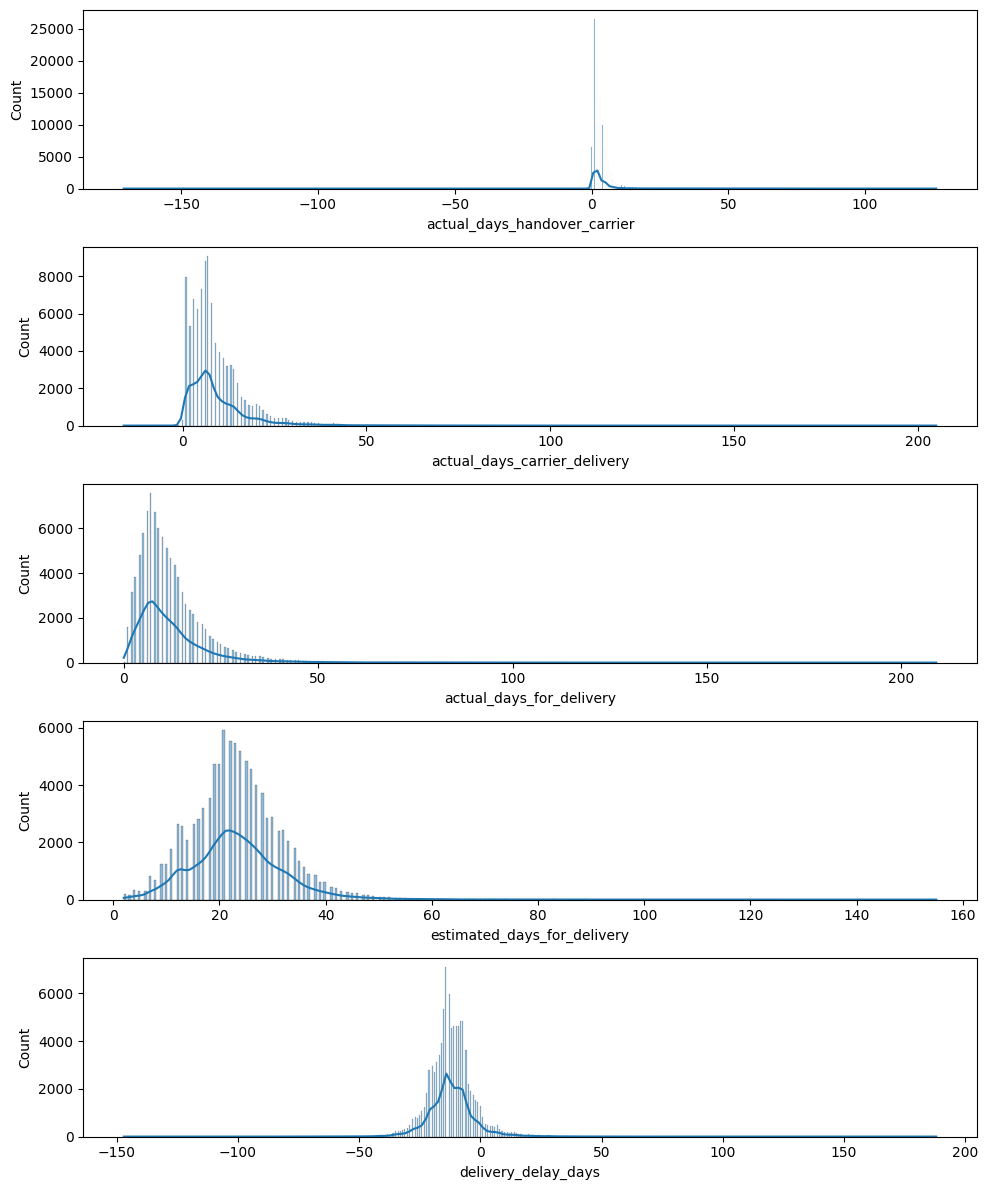

In [67]:
# PLOT THE DATA DISTRIBUTION OF THE FOLLOWING FEATURES: ACTUAL_DAYS_HANDOVER_CARRIER AND ACTUAL_DAYS_CARRIER_DELIVERY

col_distr = ['actual_days_handover_carrier', 'actual_days_carrier_delivery', 'actual_days_for_delivery','estimated_days_for_delivery','delivery_delay_days']

fig, axes = plt.subplots(len(col_distr),1, figsize= (10,12))
axes = axes.flatten()

for e, new_feature in enumerate(col_distr):
    sns.histplot(data= df_orders, x= new_feature, ax=axes[e],kde= True)
    

plt.tight_layout()
plt.show()

In [68]:
# PROVIDE THE MAIN STATISTICS FOR THE ACTUAL_DAYS_HANDOVER_CARRIER AND ACTUAL_DAYS_CARRIER_DELIVERY

df_orders[col_distr].describe()

,actual_days_handover_carrier,actual_days_carrier_delivery,actual_days_for_delivery,estimated_days_for_delivery,delivery_delay_days
count,97376.000000,96203.000000,96204.000000,98353.000000,96204.000000
mean,3.188702,9.292766,12.074041,23.307240,-11.807721
std,3.530380,8.782798,9.535667,8.647497,10.089181
min,-171.000000,-16.000000,0.000000,2.000000,-147.000000
25%,1.000000,4.000000,6.000000,18.000000,-17.000000
50%,2.000000,7.000000,10.000000,23.000000,-12.000000
75%,4.000000,12.000000,15.000000,28.000000,-7.000000
max,126.000000,205.000000,209.000000,155.000000,188.000000


In [69]:
# CHECK THE NUMBER OF RECORDS AFFECTED BY DATA ERRORS RESULTING IN NEGATIVE HANDOVER OR DELIVERY TIMES

for num, feature in enumerate(col_distr):
    n_negatives = df_orders[df_orders[feature] < 0][feature].count()
    print(f'{num+1}. {feature} contains {n_negatives} records below 0')

1. actual_days_handover_carrier contains 2 records below 0
2. actual_days_carrier_delivery contains 16 records below 0
3. actual_days_for_delivery contains 0 records below 0
4. estimated_days_for_delivery contains 0 records below 0
5. delivery_delay_days contains 88381 records below 0


In [70]:
# ADD A COLUMN CHECKING WHETHER THE CARRIER HANDOVER OCCURRED BEFORE THE MEDIAN NUMBER OF DAYS USED FOR THIS STEP.
# THE MEDIAN IS USED INSTEAD OF THE MEAN BECAUSE THE DISTRIBUTION IS HIGHLY RIGHT-SKEWED.

df_orders['carrier_handover_on_time'] = df_orders['actual_days_handover_carrier'] <= df_orders['actual_days_handover_carrier'].median()

# ADD A COLUMN CHECKING WHETHER THE CARRIER DELIVERY OCCURRED BEFORE THE MEDIAN NUMBER OF DAYS USED FOR THIS STEP.
# THE MEDIAN IS USED INSTEAD OF THE MEAN BECAUSE THE DISTRIBUTION IS HIGHLY RIGHT-SKEWED.

df_orders['carrier_delivery_on_time'] = df_orders['actual_days_carrier_delivery'] <= df_orders['actual_days_carrier_delivery'].median()

**d. Final checks**

In [71]:
# PROVIDE INFORMATION ABOUT THE NUMBER OF COLUMNS AND ROWS IN THE DATA FRAME

print(f'The df_orders data frame contains {df_orders.shape[1]} columns, {df_orders.shape[0]} entries, and {df_orders.duplicated().sum()} duplicates.')

The df_orders data frame contains 33 columns, 98353 entries, and 0 duplicates.


In [72]:
# INSPECT DATAFRAME MEDTADATA INCLUDING ENTRIES, COLUMNS, NON-NULL COUNTS, AND DATA TYPES.

df_orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98353 entries, 0 to 99091
Data columns (total 33 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       98353 non-null  object        
 1   customer_id                    98353 non-null  object        
 2   order_status_real              98353 non-null  object        
 3   order_purchase_timestamp       98353 non-null  datetime64[ns]
 4   year                           98353 non-null  int32         
 5   month                          98353 non-null  object        
 6   iso_week                       98353 non-null  UInt32        
 7   order_delivered_carrier_date   97376 non-null  datetime64[ns]
 8   order_delivered_customer_date  96204 non-null  datetime64[ns]
 9   order_estimated_delivery_date  98353 non-null  datetime64[ns]
 10  customer_unique_id             98353 non-null  object        
 11  customer_zip_code_pr

**Adjusting data types from newly features**

In [73]:
# ASSIGN INTEGER AS DATA TYPE FOR THE COLUMN NUMBER_ITEMS

df_orders = df_orders.astype({'actual_days_for_delivery' : 'Int64', 'actual_days_handover_carrier' : 'Int64', 'actual_days_carrier_delivery' : 'Int64'})


# DISPLAY NEW DATA TYPE FOR COLUMN NUMBER_ITEMS

df_orders.dtypes

order_id                                 object
customer_id                              object
order_status_real                        object
order_purchase_timestamp         datetime64[ns]
year                                      int32
month                                    object
iso_week                                 UInt32
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
customer_unique_id                       object
customer_zip_code_prefix                  int64
customer_city                            object
customer_state                           object
number_items                              Int64
gmv_order                               float64
order_freight                           float64
is_canceled                                bool
is_lost                                    bool
is_delivered                               bool
estimated_days_for_delivery             

### **2. Ordered items**

The most relevant KPIs are extracted from the order_items DataFrame and merged with KPIs from other sources, such as product category, order status, and order purchase timestamp.

**a. Data frames adjustments**

In [74]:
# DEFINE THE DF_ITEMS DATA FRAME BASED ON THE ORDER_ITEMS_FINAL CONSIDERING ONLY THE ORDERS CONTAINED IN THE DF_ORDERS DATA FRAME TO GUARANTEED DATA CONSISTENCY

df_items = order_items_final[order_items_final['order_id'].isin(df_orders['order_id'])].copy()

In [75]:
# BREAK THE CODE IF ALL THE ORDER_ID FROM THE ORDER_ITEMS_FINAL DATA FRAME ARE NOT INCLUDED IN THE DF_ORDERS DATA FRAME

assert df_orders['order_id'].isin(df_items['order_id']).all()


In [76]:
# IDENTIFY IF ALL PRODUCT_ID CONTAINED IN DF_ITEMS (LEFT TABLE) ARE INCLUDED IN THE PRODUCTS_FINAL DATA FRAME

df_items['product_id'].isin(products_final['product_id']).value_counts()

product_id
True    112279
Name: count, dtype: int64

In [77]:
# BREAK THE CODE IF ANY OF THE PRODUCT_IDS IN DF_ITEMS IS NOT INCLUDED IN THE PRODUCTS_FINAL DATA FRAME

assert df_items['product_id'].isin(products_final['product_id']).all()

**b. Merging the frames**

In [78]:
# MERGE DATA FRAMES STEP BY STEP

df_items = df_items.merge(products_final, on='product_id', how='left', validate='many_to_one')
df_items = df_items.merge(orders_final, on='order_id', how='left', validate='many_to_one')

# DISPLAY THE TOP THREE ROWS OF THE NEWLY MERGED DATA FRAME

df_items.head(3)

,order_id,product_id,seller_id,order_item_id,price,freight_value,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_id,order_status_real,order_purchase_timestamp,year,month,iso_week,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,1,58.9,13.29,cool_stuff,650.0,28.0,9.0,14.0,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017,September,37,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,1,239.9,19.93,pet_shop,30000.0,50.0,30.0,40.0,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017,April,17,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,1,199.0,17.87,moveis_decoracao,3050.0,33.0,13.0,33.0,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018,January,2,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05


In [79]:
df_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112279 entries, 0 to 112278
Data columns (total 20 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       112279 non-null  object        
 1   product_id                     112279 non-null  object        
 2   seller_id                      112279 non-null  object        
 3   order_item_id                  112279 non-null  int64         
 4   price                          112279 non-null  float64       
 5   freight_value                  112279 non-null  float64       
 6   product_category_name          112279 non-null  object        
 7   product_weight_g               112261 non-null  float64       
 8   product_length_cm              112261 non-null  float64       
 9   product_height_cm              112261 non-null  float64       
 10  product_width_cm               112261 non-null  float64       
 11  

**Adjusting data frame**

In [80]:
# RENAME COLUMN PRICE

df_items.rename(columns={'price' : 'gmv_item'}, inplace= True)

In [81]:
# DROP COLUMN CUSTOMER_ID AND SELLER_ID AS THEY LACKS IN RELEVANCE FOR THIS DATA FRAME

df_items = df_items.drop(columns=['customer_id', 'seller_id'], errors= 'ignore')

**Handling Nulls**

The null values obtained are expected and do not represent a problem for analysis

In [82]:
df_items.isnull().sum()

order_id                            0
product_id                          0
order_item_id                       0
gmv_item                            0
freight_value                       0
product_category_name               0
product_weight_g                   18
product_length_cm                  18
product_height_cm                  18
product_width_cm                   18
order_status_real                   0
order_purchase_timestamp            0
year                                0
month                               0
iso_week                            0
order_delivered_carrier_date     1157
order_delivered_customer_date    2406
order_estimated_delivery_date       0
dtype: int64

**c. Feature engeeniring**

Additional features have been engineered to capture if the article has been involved in successfull deliveries, cancelations, or losses.

In [83]:
df_items.describe().round(2)

,order_item_id,gmv_item,freight_value,product_weight_g,product_length_cm,product_height_cm,product_width_cm,order_purchase_timestamp,year,iso_week,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,112279.0,112279.00,112279.00,112261.00,112261.00,112261.00,112261.00,112279,112279.00,112279.0,111122,109873,112279
mean,1.2,120.61,19.99,2093.06,30.15,16.59,23.00,2018-01-02 11:47:16.054382080,2017.55,24.29,2018-01-06 10:01:55.020005120,2018-01-15 20:47:19.834554368,2018-01-26 05:19:42.386733312
min,1.0,0.85,0.00,0.00,7.00,2.00,6.00,2017-01-05 11:56:06,2017.00,1.0,2017-01-06 12:43:41,2017-01-11 13:14:05,2017-02-01 00:00:00
25%,1.0,39.90,13.08,300.00,18.00,8.00,15.00,2017-09-15 08:43:15.500000,2017.00,12.0,2017-09-19 18:33:18.249999872,2017-09-27 22:39:48,2017-10-06 00:00:00
50%,1.0,74.99,16.26,700.00,25.00,13.00,20.00,2018-01-20 20:57:48,2018.00,23.0,2018-01-24 23:09:38.500000,2018-02-03 15:53:07,2018-02-16 00:00:00
75%,1.0,134.90,21.15,1800.00,38.00,20.00,30.00,2018-05-04 23:19:18,2018.00,34.0,2018-05-08 14:08:00,2018-05-15 21:47:23,2018-05-28 00:00:00
max,21.0,6735.00,409.68,40425.00,105.00,105.00,118.00,2018-08-29 15:00:37,2018.00,52.0,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00
std,0.7,183.64,15.81,3750.76,16.15,13.44,11.71,NaN,0.50,14.05,NaN,NaN,NaN


In [84]:
# ADD COLUMNS A FLAG IF ORDERS HAVE BEEN CANCELED, HAS FAILED DELIVERY; OR IT HAS BEN SUCCESFULLLY DELIVERED

df_items['is_canceled'] = df_items['order_status_real'] == 'canceled'
df_items['is_lost'] = df_items['order_status_real'] == 'lost'
df_items['is_delivered'] = df_items['order_status_real'] == 'delivered'


In [85]:
# ADD A COLUMN WITH THE REAL GMV DELIVERED 

df_items['gmv_delivered'] = np.where(df_items['is_delivered'], df_items['gmv_item'], 0)

# ADD COLUMNS WITH THE TOTAL GMV INVOLVED IN CANCELATIONS, LOST PARCELS, AND THE COMBINATION OF BOTH

df_items['gmv_canceled'] = np.where(df_items['is_canceled'], df_items['gmv_item'], 0)
df_items['gmv_lost'] = np.where(df_items['is_lost'], df_items['gmv_item'], 0)
df_items['gmv_failed'] = df_items['gmv_canceled'] + df_items['gmv_lost']

**d. Final checks**

In [86]:
# DISPLAY THE TOP 3 ROWS OF DATA FRAME

df_items.head(3)

,order_id,product_id,order_item_id,gmv_item,freight_value,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,...,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_canceled,is_lost,is_delivered,gmv_delivered,gmv_canceled,gmv_lost,gmv_failed
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,1,58.9,13.29,cool_stuff,650.0,28.0,9.0,14.0,...,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,False,False,True,58.9,0.0,0.0,0.0
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,1,239.9,19.93,pet_shop,30000.0,50.0,30.0,40.0,...,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,False,False,True,239.9,0.0,0.0,0.0
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,1,199.0,17.87,moveis_decoracao,3050.0,33.0,13.0,33.0,...,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,False,False,True,199.0,0.0,0.0,0.0


In [87]:
# PROVIDE INFORMATION ABOUT THE NUMBER OF COLUMNS AND ROWS IN THE DATA FRAME

print(f'The df_items data frame contains {df_items.shape[1]} columns, {df_items.shape[0]} entries, and {df_items.duplicated().sum()} duplicates.')


The df_items data frame contains 25 columns, 112279 entries, and 0 duplicates.


In [88]:
# INSPECT DATAFRAME MEDTADATA INCLUDING ENTRIES, COLUMNS, NON-NULL COUNTS, AND DATA TYPES.

df_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112279 entries, 0 to 112278
Data columns (total 25 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       112279 non-null  object        
 1   product_id                     112279 non-null  object        
 2   order_item_id                  112279 non-null  int64         
 3   gmv_item                       112279 non-null  float64       
 4   freight_value                  112279 non-null  float64       
 5   product_category_name          112279 non-null  object        
 6   product_weight_g               112261 non-null  float64       
 7   product_length_cm              112261 non-null  float64       
 8   product_height_cm              112261 non-null  float64       
 9   product_width_cm               112261 non-null  float64       
 10  order_status_real              112279 non-null  object        
 11  

**Creating a file specifically for a Tableau side project**

In [89]:
# CREATE A CSV FILE FOR A SIDE TABLEAU PROJECT

df_items.to_csv('cleaned_data/items.csv', index= False)

### **3. Customers**

**a. Data frames adjustments**

In [90]:
# GENERATE A COPY OR THE CUSTOMERS_FINAL AND THE DF_ORDERS FRAMES TO GUARANTEED DATA CONSISTENCY

customers_final_copy = customers_final[['customer_unique_id',
                      'customer_zip_code_prefix',
                      'customer_city',
                      'customer_state']].drop_duplicates('customer_unique_id')

df_orders_copy = df_orders.copy()

In [91]:
# DEFINE AN AGGREGATED FRAME WITH THE RELEVENAT COLUMNS FROM THE ORDER_ITEMS DATA FRAME

agg_orders = df_orders_copy.groupby(by= 'customer_unique_id', as_index= False).agg(
                                                                        n_orders = ('order_id', 'count'),
                                                                        n_delivered = ('is_delivered', 'sum'),
                                                                        n_cancellations = ('is_canceled', 'sum'),
                                                                        n_lost_parcels = ('is_lost', 'sum'),
                                                                        gmv_order = ('gmv_order', 'sum'),
                                                                        gmv_delivered = ('gmv_delivered', 'sum'),
                                                                        gmv_canceled = ('gmv_canceled', 'sum'),
                                                                        gmv_lost = ('gmv_lost', 'sum'),
                                                                        gmv_failed = ('gmv_failed', 'sum'),
                                                                        order_freight = ('order_freight', 'sum'),
                                                                        avg_gmv_delivered = ('gmv_delivered', 'mean'),
                                                                        first_order_date = ('order_purchase_timestamp', 'min'),
                                                                        last_order_date = ('order_purchase_timestamp', 'max'),
                                                                        avg_estimated_days_for_delivery = ('estimated_days_for_delivery', 'mean'),
                                                                        avg_actual_days_for_delivery = ('actual_days_for_delivery', 'mean')
                                                                        )

**Are the customer_unique_ids from agg_orders included in the customer_final_copy data frame?**

In [92]:
# CHECK IF ALL CUSTOMER_UNIQUE_ID FROM THE DF_ORDERS DATA FRAME ARE INCLUDED OR NOT IN THE CUSTOMER_FINAL_COPY DATA FRAME

if agg_orders['customer_unique_id'].isin(customers_final_copy['customer_unique_id']).all():
    print('All customer_unique_id values from the df_orders data frame are present in the customer_final_copy data frame')
    print('Any null values generated during the merge correspond to customers who have never made a purchase')

else:
    print('Not all customer_unique_id values are included in the customer_final_copy frame.')
    print('If you merge the data frames as they are, any null values generated by the merge won\'t necessary correspond to customers who have never made a purchase')

All customer_unique_id values from the df_orders data frame are present in the customer_final_copy data frame
Any null values generated during the merge correspond to customers who have never made a purchase


In [93]:
# BREAK THE CODE IF ANY OF THE CUSTOMER_UNIQUE_ID IN AGG_ORDERS IS NOT INCLUDED IN THE CUSTOMER_FINAL_COPY DATA FRAME

assert agg_orders['customer_unique_id'].isin(customers_final_copy['customer_unique_id']).all()

**b. Merging the frames**

In [94]:
# MERGE AGG_ORDERS INTO CUSTOMERS_FINAL_COPY
    
df_customers = customers_final_copy.merge(right= agg_orders, how= 'left', on= 'customer_unique_id')
    
# DISPLAY THE TOP 3 ROWS OF THE NEWLY MERGED DATA FRAME

df_customers.head(3)

,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,n_orders,n_delivered,n_cancellations,n_lost_parcels,gmv_order,gmv_delivered,gmv_canceled,gmv_lost,gmv_failed,order_freight,avg_gmv_delivered,first_order_date,last_order_date,avg_estimated_days_for_delivery,avg_actual_days_for_delivery
0,861eff4711a542e4b93843c6dd7febb0,14409,franca,São Paulo,1.0,1.0,0.0,0.0,124.99,124.99,0.0,0.0,0.0,21.88,124.99,2017-05-16 15:05:35,2017-05-16 15:05:35,19.0,8.0
1,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,São Paulo,1.0,1.0,0.0,0.0,289.00,289.00,0.0,0.0,0.0,46.48,289.00,2018-01-12 20:48:24,2018-01-12 20:48:24,24.0,16.0
2,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,São Paulo,1.0,1.0,0.0,0.0,139.94,139.94,0.0,0.0,0.0,17.79,139.94,2018-05-19 16:07:45,2018-05-19 16:07:45,24.0,26.0


In [95]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96096 entries, 0 to 96095
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   customer_unique_id               96096 non-null  object        
 1   customer_zip_code_prefix         96096 non-null  int64         
 2   customer_city                    96096 non-null  object        
 3   customer_state                   96096 non-null  object        
 4   n_orders                         95121 non-null  float64       
 5   n_delivered                      95121 non-null  float64       
 6   n_cancellations                  95121 non-null  float64       
 7   n_lost_parcels                   95121 non-null  float64       
 8   gmv_order                        95121 non-null  float64       
 9   gmv_delivered                    95121 non-null  float64       
 10  gmv_canceled                     95121 non-null  float64  

**Assigning correct data types**

In [96]:
# ASSIGN CORRECT DATA TYPES

df_customers = df_customers.astype({'n_orders' : 'Int64','n_delivered' : 'Int64', 'n_cancellations' : 'Int64', 'n_lost_parcels' : 'Int64'})
df_customers.dtypes



customer_unique_id                         object
customer_zip_code_prefix                    int64
customer_city                              object
customer_state                             object
n_orders                                    Int64
n_delivered                                 Int64
n_cancellations                             Int64
n_lost_parcels                              Int64
gmv_order                                 float64
gmv_delivered                             float64
gmv_canceled                              float64
gmv_lost                                  float64
gmv_failed                                float64
order_freight                             float64
avg_gmv_delivered                         float64
first_order_date                   datetime64[ns]
last_order_date                    datetime64[ns]
avg_estimated_days_for_delivery           float64
avg_actual_days_for_delivery              Float64
dtype: object

**c. Feature engeeniring**

As shown in the table, the customer base is highly skewed toward one-time buyers. The 75th percentile of n_orders equals 1, meaning that at least 75% of customers have placed only a single order, which is also reflected by the low average number of orders per customer (mean = 1.03).

Nevertheless, there are a few highly engaged customers, with the maximum number of orders reaching 16, indicating the presence of a small group of repeat buyers.

Customer spending also shows strong variability. While the median total GMV per customer is about 89.9 and the 75th percentile is 155, the maximum GMV reaches 13,440, suggesting that a small number of customers generate disproportionately high revenue.

Overall, these statistics highlight a long-tail customer distribution, where most customers purchase only once and spend relatively small amounts, while a limited group of customers contributes significantly more through repeated or higher-value purchases.

Based on this behavior, additional features are going to be engineered to segment customers in order to design targeted actions and retention strategies.

In [97]:
# DISPLAY MAIN STATISTICS FOR ALL NUMERICAL FEATURES

df_customers.describe().round(2)

,customer_zip_code_prefix,n_orders,n_delivered,n_cancellations,n_lost_parcels,gmv_order,gmv_delivered,gmv_canceled,gmv_lost,gmv_failed,order_freight,avg_gmv_delivered,first_order_date,last_order_date,avg_estimated_days_for_delivery,avg_actual_days_for_delivery
count,96096.00,95121.0,95121.0,95121.0,95121.0,95121.00,95121.00,95121.00,95121.00,95121.00,95121.00,95121.00,95121,95121,95121.00,93097.0
mean,35185.76,1.03,1.01,0.0,0.02,142.36,138.57,0.97,2.82,3.79,23.60,134.46,2018-01-01 21:50:55.299429376,2018-01-04 13:26:44.705490944,23.29,12.08
min,1003.00,1.0,0.0,0.0,0.0,0.85,0.00,0.00,0.00,0.00,0.00,0.00,2017-01-05 11:56:06,2017-01-05 11:56:06,2.00,0.0
25%,11405.00,1.0,1.0,0.0,0.0,47.88,44.99,0.00,0.00,0.00,14.08,44.87,2017-09-13 16:45:10,2017-09-17 19:40:28,18.00,6.0
50%,24440.00,1.0,1.0,0.0,0.0,89.90,86.90,0.00,0.00,0.00,17.60,84.90,2018-01-19 21:04:06,2018-01-22 22:35:09,23.00,10.0
75%,59035.50,1.0,1.0,0.0,0.0,155.00,150.00,0.00,0.00,0.00,25.54,149.90,2018-05-04 21:29:13,2018-05-07 13:19:03,28.00,15.0
max,99990.00,16.0,15.0,1.0,2.0,13440.00,13440.00,4599.90,2492.50,4599.90,1794.96,13440.00,2018-08-29 15:00:37,2018-08-29 15:00:37,155.00,209.0
std,29801.66,0.21,0.25,0.07,0.13,217.70,214.43,30.77,36.46,47.66,22.88,208.50,NaN,NaN,8.60,9.54


**Customer Segmentation**

Since the dataset used for this analysis is relatively old and limited in time, September 1, 2018 will be used as the reference date for calculating customer recency. This metric will play a key role in defining customer segmentation.

In [98]:
# SET A REFERENCE DATE

reference_date = pd.Timestamp('2018-09-01')

# CALCULATE RECENCY DAYS

df_customers['recency_days'] = (reference_date - df_customers['last_order_date']).dt.days

# ASSIGNS INT AS THE DATA TYPE

df_customers['recency_days'] = df_customers['recency_days'].astype('Int64')

Now, it is time to define the recency threshold, which will serve as a cutoff point to determine whether customers are considered active or have churned after a certain period of inactivity.

In [99]:
# DEFINE THRESHOLD FOR SEGMENTATION

recency_threshold = df_customers.loc[df_customers['n_orders'] > 0, 'recency_days'].median()

print(f'The recency treshold is equal to {round(recency_threshold,0)} days, equivalent to {round(recency_threshold/30, 1)} months')

The recency treshold is equal to 221.0 days, equivalent to 7.4 months


The median recency (in days) is relatively high and may not be a fully reliable metric for defining customers. Therefore, for now, the threshold will be set to 182 days (6 months) whenever the median exceeds this value.

In [100]:
# SET THE RECENCY THRESHOLD TO A MAXIMUM OF 182 DAYS (6 MONTHS), UNLESS THE MEDIAN RECENCY DAYS IS LESS THAN OR EQUAL TO THIS VALUE

recency_threshold = min(recency_threshold, 182)


It is time to define a lifetime (in days) KPI to measure the span between a customer’s first and last purchase. In some cases, customers may place multiple orders on the same day and be incorrectly classified as recurrent customers. This metric is essential to accurately identify one-time or short-lived customers, regardless of how many orders they placed.

In [101]:
# DEFINE THE CUSTOMER LIFECYCLE IN DAYS

df_customers['lifetime_days'] = (df_customers['last_order_date'] - df_customers['first_order_date']).dt.days

To define the segmentation, it is relevant to check if there are null values involved to avoid miscalculation or erros

In [102]:
df_customers[['n_orders', 'recency_days', 'lifetime_days']].isnull().sum()

n_orders         975
recency_days     975
lifetime_days    975
dtype: int64

A total of 975 customers have no recorded order information, resulting in null values across most KPIs in the dataset.

These customers will be classified as non-purchasers, based on the available data from the orders table. However, in a real-world scenario, it would be important to investigate further to confirm whether these customers truly never placed any orders or if the data is incomplete.

In [103]:
# DEFINE VARIABLES THAT WILL BE USED AS CONDITIONS AND FILL NULL VALUES ACCORDINGLY

n_orders = df_customers['n_orders'].fillna(0)
recency = df_customers['recency_days'].fillna(999)
life = df_customers['lifetime_days'].fillna(0)

Customer segmentation is defined across seven categories:

In [104]:
print(f'''1. Non-Purchaser: The customer has not placed any orders. Customers with null values are included in this group.
2. Recurrent Loyal: The customer has placed at least two orders, has a lifetime greater than zero, and has made a purchase within the last {int(recency_threshold / 2)} days ({int(recency_threshold / 2 / 30)} months).
3. Recurrent At-Risk: The customer has placed at least two orders and has a lifetime greater than zero but made a purchase in the last {int(recency_threshold / 2 + 1)} - {int(recency_threshold)} days ({int(recency_threshold / 2 / 30 + 1)} - {int(recency_threshold / 30)} months).
4. Recurrent Lost: The customer has placed at least two orders and has a lifetime greater than zero but has not made a purchase in more than {int(recency_threshold)} days ({int(recency_threshold / 30)} months).
5. New First Order: The Customer has placed the first order in the last {int(recency_threshold / 2)} days ({int(recency_threshold / 2 / 30)} months).
6. New at-Risk One-Timer: The customer has placed only one order, and it occurred within the last {int(recency_threshold / 2 + 1)} - {int(recency_threshold)} days ({int(recency_threshold / 2 / 30 + 1)} - {int(recency_threshold / 30)} months).
7. Lost One-Timer: The customer has placed only one order and has not been active in more than {int(recency_threshold)} days ({int(recency_threshold / 30)} months).

If the category "Need to be checked" appears, it indicates that the segmentation logic has not been properly applied and some customers remain unclassified.

Note:

Customers that have made more than one purchase on the same day but haven't been active after that (life = 0) are treated as New First Order, New at-Risk One-Timer,
and Lost One-Timer based on their recency'''
)



1. Non-Purchaser: The customer has not placed any orders. Customers with null values are included in this group.
2. Recurrent Loyal: The customer has placed at least two orders, has a lifetime greater than zero, and has made a purchase within the last 91 days (3 months).
3. Recurrent At-Risk: The customer has placed at least two orders and has a lifetime greater than zero but made a purchase in the last 92 - 182 days (4 - 6 months).
4. Recurrent Lost: The customer has placed at least two orders and has a lifetime greater than zero but has not made a purchase in more than 182 days (6 months).
5. New First Order: The Customer has placed the first order in the last 91 days (3 months).
6. New at-Risk One-Timer: The customer has placed only one order, and it occurred within the last 92 - 182 days (4 - 6 months).
7. Lost One-Timer: The customer has placed only one order and has not been active in more than 182 days (6 months).

If the category "Need to be checked" appears, it indicates that 

In [105]:
# DEFINE CONDITIONS

segment_conditions = [
    (n_orders == 0),  # NON-PURCHASER
    (n_orders > 1) & (life > 0) & (recency <= recency_threshold / 2), # RECURRENT LOYAL
    (n_orders > 1) & (life > 0) & (recency > recency_threshold / 2) & (recency <= recency_threshold), # RECURRENT AT-RISK
    (n_orders > 1) & (life > 0) & (recency > recency_threshold), # RECCURENT LOST
    ((n_orders >= 1) & (life == 0) & (recency <= recency_threshold / 2)), # NEW FIRST ORDER
    ((n_orders >= 1) & (life == 0) & (recency > recency_threshold / 2) & (recency <= recency_threshold)), # NEW AT-RISK ONE-TIMER
    ((n_orders >= 1) & (life == 0) & (recency > recency_threshold)) # LOST ONE-TIMER
]

# ASSIGN LABELS BASED ON CONDITIONS

segment_labels = [
    'Non-Purchaser',
    'Recurrent Loyal', 
    'Recurrent at-Risk',
    'Recurrent Lost',
    'New First Order',
    'New at-Risk One-Timer',
    'Lost One-Timer'
]

# DEFINE SEGMENTATION BASED ON CONDITIONS

df_customers['customer_segment'] = np.select(segment_conditions, segment_labels, default='Need to be checked')

In [106]:
# GENERATE A NEW FRAME BASED ON THE SEGMENTED CUSTOMERS

print(df_customers.groupby('customer_segment', as_index= False).agg(
                                                    n_customers = ('customer_unique_id', 'count'),
                                                    n_orders = ('n_orders', 'sum'),
                                                    gmv_delivered = ('gmv_delivered', 'sum'),
                                                    lifetime = ('lifetime_days', 'mean')
))

        customer_segment  n_customers  n_orders  gmv_delivered    lifetime
0         Lost One-Timer        55276     55975     7412403.32    0.000000
1        New First Order        18102     18173     2467517.04    0.000000
2  New at-Risk One-Timer        19693     19802     2751900.50    0.000000
3          Non-Purchaser          975         0           0.00         NaN
4         Recurrent Lost          949      2008      250656.62   88.971549
5        Recurrent Loyal          559      1224      154974.03  170.245081
6      Recurrent at-Risk          542      1171      143575.62  131.723247


To ensure complete segment coverage, an assertion validates that every customer has been assigned to a defined segment, raising an error if any record requires manual review.

In [107]:
# BREAK THE CODE IF ANY CUSTOMER DOES NOT FIT THE SEGMENTATION LOGIC

unchecked = df_customers[df_customers['customer_segment'] == 'Need to be checked']

assert len(unchecked) == 0, (
    f'{len(unchecked)} Customer do not fit the segmentation logic.\n'
    f'Ejemplos:\n{unchecked.head(3)}'
)

**Risk Score**

Both scores are closely tied to the number of orders placed by each customer. However, given that approximately 97% of customers have made only a single purchase, this variable provides very limited differentiation across the dataset. As a result, relying heavily on it could introduce bias without adding meaningful predictive value. To mitigate this, its influence is intentionally reduced within the overall scoring model.

The risk score is therefore primarily driven by recency, which accounts for at least 80% of the total. Lost orders contribute 15%, while cancellations account for only 5%. The relatively low weight assigned to cancellations reflects the lack of available data explaining why they occurred. Without this context, cancellations cannot be reliably interpreted as a strong risk signal.

In contrast, lost orders are assumed to have a more direct impact on customer experience, which may increase the likelihood of churn. In a real-world scenario, it would be important to further investigate and differentiate the underlying causes of cancellations and lost orders to refine these weightings and improve the model’s accuracy.

In [108]:
# DEFINE THE VARIABLES THAT WILL BE USE FOR THE SCORE

delivered_orders = df_customers['n_delivered'].fillna(0)
canceled_orders = df_customers['n_cancellations'].fillna(0)
lost_orders = df_customers['n_lost_parcels'].fillna(0)
total_orders = df_customers['n_orders'].fillna(0)

# ADD THE COLUMN RISK_SCORE BASED ON 80% WEIGHT ON RECENCY (NORMALIZED RANK) TO DETECT INACTIVITY AND 20% WEIGHT ON LOGISTICS INCIDENTS (CANCELLATIONS (5%) + LOST PARCELS (15%))

df_customers['risk_score'] = (canceled_orders / total_orders).fillna(0) * 0.05 + (lost_orders / total_orders).fillna(0) * 0.15 + (df_customers['recency_days'].rank(pct=True)) * 0.8



**Value Score**

The score is primarily driven by the total GMV, both delivered and lost. Lost GMV is included because it reflects situations where the customer expected to receive their order, but the parcel was lost during the process without any action from the customer—unlike cancellations, which may be customer-initiated.

As with previous metrics, the number of orders plays a limited role due to the high proportion of one-time customers (>97%) in the dataset, which reduces its ability to meaningfully differentiate behavior.

The average GMV per order (delivered + lost) contributes approximately 20% to the overall score. 

On the other hand, cancellations will be penalized by reducing the score 0.03 per cancellation only if customers have more than one order and one of them has been delivered or lost, and the other one canceled.

In [109]:
# DEFINE THE VARIABLES THAT WILL BE USE FOR THE SCORE

delivered_gmv = df_customers['gmv_delivered'].fillna(0)
lost_gmv = df_customers['gmv_lost'].fillna(0)
canceled_gmv = df_customers['gmv_canceled'].fillna(0)
avg_gmv = (delivered_gmv + lost_gmv) / (delivered_orders + lost_orders).fillna(0)


penalty_cancellations = np.where(
    (total_orders > 1) &
    (canceled_orders > 0) &
    ((delivered_orders + lost_orders) > 0),
    canceled_orders * 0.03,
    0
)


basic_value_score = ((delivered_gmv + lost_gmv).rank(pct= True) * 0.8 
                               + (delivered_orders + lost_orders).rank(pct=True) * 0.05 
                               + (avg_gmv).rank(pct=True) * 0.15 
                               - penalty_cancellations
                               )

#  ADD A COLUMN WITH THE VALUE_SCORE WITH GMV DELIVERED + GMV LOST (80%), NUMBER OF ORDERS DELIVERED AND LOST (0.05%), AND THE AVG GMV OF THOSE ORDERS (15%).
# A PENALTY WILL BE ADDED ONLY IF THE CUSTOMER HAS MORE THAN 1 ORDER, ONE OF THEM HAS BEEN DELIVERED OR LOST, AND ONE OF THEM HAS BEEN CANCELED 

df_customers['value_score'] = np.where(
    (basic_value_score >= 0),
    basic_value_score,
    0
)


**GMV Rank**

In [110]:
#ADD A COLUMN ADDING THE GMV RANK PER CUSTOMER

df_customers['gmv_rank'] = (df_customers['gmv_delivered'] + df_customers['gmv_lost']).rank(pct= True)

In [111]:
# DISPLAY THE TOP 3 ROWS OF DATA FRAME

df_customers.head(3)

,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,n_orders,n_delivered,n_cancellations,n_lost_parcels,gmv_order,gmv_delivered,...,first_order_date,last_order_date,avg_estimated_days_for_delivery,avg_actual_days_for_delivery,recency_days,lifetime_days,customer_segment,risk_score,value_score,gmv_rank
0,861eff4711a542e4b93843c6dd7febb0,14409,franca,São Paulo,1,1,0,0,124.99,124.99,...,2017-05-16 15:05:35,2017-05-16 15:05:35,19.0,8.0,472,0.0,Lost One-Timer,0.726228,0.657214,0.661436
1,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,São Paulo,1,1,0,0,289.00,289.00,...,2018-01-12 20:48:24,2018-01-12 20:48:24,24.0,16.0,231,0.0,Lost One-Timer,0.424896,0.883951,0.902776
2,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,São Paulo,1,1,0,0,139.94,139.94,...,2018-05-19 16:07:45,2018-05-19 16:07:45,24.0,26.0,104,0.0,New at-Risk One-Timer,0.177776,0.702851,0.709859


**d. Final checks**

In [112]:
# PROVIDE INFORMATION ABOUT THE NUMBER OF COLUMNS AND ROWS IN THE DATA FRAME

print(f'The df_customers data frame contains {df_customers.shape[1]} columns, {df_customers.shape[0]} entries, '
      f'which is equal to the number of rows of unique customers {customers_final_copy.customer_unique_id.nunique()} '
      f'in the customers_final frame and {df_customers.duplicated().sum()} duplicates.')



The df_customers data frame contains 25 columns, 96096 entries, which is equal to the number of rows of unique customers 96096 in the customers_final frame and 0 duplicates.


In [113]:
# INSPECT DATAFRAME MEDTADATA INCLUDING ENTRIES, COLUMNS, NON-NULL COUNTS, AND DATA TYPES.

df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96096 entries, 0 to 96095
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   customer_unique_id               96096 non-null  object        
 1   customer_zip_code_prefix         96096 non-null  int64         
 2   customer_city                    96096 non-null  object        
 3   customer_state                   96096 non-null  object        
 4   n_orders                         95121 non-null  Int64         
 5   n_delivered                      95121 non-null  Int64         
 6   n_cancellations                  95121 non-null  Int64         
 7   n_lost_parcels                   95121 non-null  Int64         
 8   gmv_order                        95121 non-null  float64       
 9   gmv_delivered                    95121 non-null  float64       
 10  gmv_canceled                     95121 non-null  float64  

**Creating a file specifically for a Tableau side project**

In [114]:
# CREATE A CSV FILE FOR A SIDE TABLEAU PROJECT

df_customers.to_csv('cleaned_data/customers.csv', index= False)